In [1]:
import os
import numpy as np
import re
import emoji
import pandas as pd
import wandb

from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, multilabel_confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import get_linear_schedule_with_warmup
from transformers.integrations import WandbCallback

from sklearn.metrics import f1_score, hamming_loss
from transformers import Trainer
from transformers import TrainingArguments, EarlyStoppingCallback

In [2]:
config = {
    'data_dir': './go_emotions',
    'model_name': 'roberta-base',
    
    'num_labels':28,
    'max_length': 128,
    'batch_size': 16,

    'focal_alpha': 1,
    'focal_gamma': 2,

    'num_train_epochs': 6,
    'learning_rate': 2e-5,
    'weight_decay': 0.01,
    'max_grad_norm': 1.0
}
SPECIAL_TOKENS = ['[NAME]', '[RELIGION]']
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load Dataset

In [3]:
pd.set_option('display.max_colwidth', None)

In [4]:
train = f"./{config['data_dir']}/train.tsv"
dev = f"./{config['data_dir']}/dev.tsv"
test = f"./{config['data_dir']}/test.tsv"

columns = ['text', 'labels', 'ID']
train_df = pd.read_csv(train, sep='\t', header=None, names=columns)
dev_df = pd.read_csv(dev, sep='\t', header=None, names=columns)
test_df = pd.read_csv(test, sep='\t', header=None, names=columns)

full_df = pd.concat([train_df, dev_df, test_df], axis=0)
full_df = full_df.reset_index(drop=True)
full_df['labels'] = full_df['labels'].apply(lambda x: [int(i) for i in str(x).split(',')])

In [5]:
def preprocess_text(text):
    text = emoji.demojize(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'/?u/\S+', '[USER]', text)
    text = re.sub(r'/?r/\S+', '[SUBREDDIT]', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

full_df['text'] = full_df['text'].apply(preprocess_text)
full_df.head()

,text,labels,ID
0,My favourite food is anything I didn't have to cook myself.,[27],eebbqej
1,"Now if he does off himself, everyone will think hes having a laugh screwing with people instead of actually dead",[27],ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj
3,To make her feel threatened,[14],ed7ypvh
4,Dirty Southern Wankers,[3],ed0bdzj


# Preprocess data

In [6]:
#tạo one-hot label
multi_labels = MultiLabelBinarizer(classes=range(28))
y = multi_labels.fit_transform(full_df['labels'])
df_y = pd.DataFrame({
    "OneHot_list": y.tolist()
})

full_df = full_df.reset_index(drop=True)
df_oneHot = pd.concat([full_df, df_y], axis=1)

In [7]:
# Tách train/dev/test theo tỷ lệ 8/1/1, dùng MultilabelStratifiedShuffleSplit
X = df_oneHot.drop(columns=["OneHot_list"])
y = np.array(df_oneHot["OneHot_list"].tolist())

msss = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

for train_idx, temp_idx in msss.split(X, y):
    X_train, X_temp = X.iloc[train_idx], X.iloc[temp_idx]
    y_train, y_temp = y[train_idx], y[temp_idx]

msss_2 = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.5,
    random_state=42
)

for dev_idx, test_idx in msss_2.split(X_temp, y_temp):
    df_dev, df_test = X_temp.iloc[dev_idx], X_temp.iloc[test_idx]
    y_dev, y_test = y_temp[dev_idx], y_temp[test_idx]

df_train = X_train
df_train = df_train.drop(columns=["ID"])
df_dev = df_dev.drop(columns=["ID"])
df_test = df_test.drop(columns=["ID"])

# Tokenizer and load model

In [8]:
tokenizer = AutoTokenizer.from_pretrained(config['model_name'])
model = AutoModelForSequenceClassification.from_pretrained(
    config['model_name'],
    num_labels=config['num_labels'],
    problem_type="multi_label_classification"
)
model.to(device)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [9]:
def tokenize_roberta(texts):
    return tokenizer(
        texts.tolist(),
        padding='max_length',
        truncation=True,
        max_length=config['max_length'],
        return_tensors='pt'
    )

tokenizer.add_special_tokens({'additional_special_tokens': SPECIAL_TOKENS})
model.resize_token_embeddings(len(tokenizer))
print(f"size of new vocab: {len(tokenizer)}")

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


size of new vocab: 50267


# DataLoaders

In [10]:
class GoEmotionsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.FloatTensor(label)
        }

In [11]:
train_dataset = GoEmotionsDataset(
    df_train['text'].values, 
    y_train, 
    tokenizer, 
    config['max_length']
)

val_dataset = GoEmotionsDataset(
    df_dev['text'].values, 
    y_dev, 
    tokenizer, 
    config['max_length']
)

test_dataset = GoEmotionsDataset(
    df_test['text'].values, 
    y_test, 
    tokenizer, 
    config['max_length']
)

train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config['batch_size'])
test_loader = DataLoader(test_dataset, batch_size=config['batch_size'])

print(f"Number of sample in batch train: {len(train_loader)}")

Number of sample in batch train: 2716


# Train model

In [12]:
# tính metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits)) 
    predictions = (probs > 0.5).astype(int)
    
    return {
        'f1_micro': f1_score(labels, predictions, average='micro'),
        'f1_macro': f1_score(labels, predictions, average='macro'),
        'hamming_loss': hamming_loss(labels, predictions)
    }

In [13]:
class FocalLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        alpha, gamma = config['focal_alpha'], config['focal_gamma']
        bce_loss = torch.nn.functional.binary_cross_entropy_with_logits(logits, labels, reduction='none')
        probas = torch.sigmoid(logits)
        p_t = probas * labels + (1 - probas) * (1 - labels)
        loss = alpha * (1 - p_t)**gamma * bce_loss
        
        return (loss.mean(), outputs) if return_outputs else loss.mean()

In [14]:
os.environ["WANDB_PROJECT"] = 'GoEmotions_RoBERTa-base'

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=config['num_train_epochs'],
    per_device_train_batch_size=config['batch_size'],
    per_device_eval_batch_size=config['batch_size'],
    learning_rate=config['learning_rate'],
    weight_decay=config['weight_decay'],
    max_grad_norm=config['max_grad_norm'],

    warmup_ratio=0.06,
    adam_epsilon=1e-6,
    lr_scheduler_type="cosine",

    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=4,
    load_best_model_at_end=True,
    metric_for_best_model="f1_micro",
    
    report_to="wandb", 
    logging_steps=50,
    fp16=torch.cuda.is_available(),
)
# Khởi tạo Trainer
trainer = FocalLossTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [15]:
# chạy trainer
trainer.train()

trainer.save_model("./goemotions_final_model")
tokenizer.save_pretrained("./goemotions_final_model")
wandb.finish()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\USER\_netrc.
wandb: Currently logged in as: kthnh224 (kthnh224-fpt-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Hamming Loss,Runtime,Samples Per Second,Steps Per Second
1,0.024295,0.023756,0.552223,0.409536,0.031437,12.279200,440.664000,27.608000
2,0.022642,0.022985,0.570537,0.482158,0.030883,12.659700,427.418000,26.778000
3,0.019423,0.023096,0.586384,0.488900,0.030876,12.726400,425.181000,26.638000
4,0.015516,0.023800,0.581594,0.510528,0.031358,12.170600,444.595000,27.854000
5,0.015281,0.024596,0.584880,0.516190,0.031893,12.240000,442.075000,27.696000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

eval/f1_macro,▁▆▆██
eval/f1_micro,▁▅█▇█
eval/hamming_loss,▅▁▁▄█
eval/loss,▄▁▁▅█
eval/runtime,▂▇█▁▂
eval/samples_per_second,▇▂▁█▇
eval/steps_per_second,▇▂▁█▇
train/epoch,▁▂▂▂▂▂▂▂▂▂▃▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▆▆▆▆▆▇▇▇▇████
train/global_step,▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇████
train/grad_norm,█▅▁▁▂▃▂▄▂▁▃▃▄▆▄▂▃▁▄▃▂▁▂▄▂▄▂▃▂▁▃▆▃▅▃▄▄▄▆▃
+2,...


# Evaluation

In [16]:
emotion_labels = [
    'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 
    'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 
    'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 
    'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 
    'relief', 'remorse', 'sadness', 'surprise', 'neutral'
]

In [31]:
#lấy model từ epoch thứ 3
checkpoint_path = "./results/checkpoint-10864" 

model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint_path,
    num_labels=config['num_labels'],
    problem_type="multi_label_classification"
)
model.to(device)
trainer.model = model

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [32]:
# Lấy dự đoán từ tập Val và Test
trainer.remove_callback(WandbCallback)

val_predictions = trainer.predict(val_dataset)
test_predictions = trainer.predict(test_dataset)

val_probs = torch.sigmoid(torch.from_numpy(val_predictions.predictions)).numpy()
test_probs = torch.sigmoid(torch.from_numpy(test_predictions.predictions)).numpy()

val_labels = val_predictions.label_ids
test_labels = test_predictions.label_ids

In [37]:
def find_best_thresholds(probabilities, true_labels, num_labels):
    best_thresholds = np.ones(num_labels) * 0.5
    thresholds = np.arange(0.01, 0.99, 0.01)
    
    for i in range(num_labels):
        best_f1 = 0
        current_label_probs = probabilities[:, i]
        current_label_true = true_labels[:, i]
        
        for thresh in thresholds:
            current_label_preds = (current_label_probs >= thresh).astype(int)
            score = f1_score(current_label_true, current_label_preds, zero_division=0)
            
            if score > best_f1:
                best_f1 = score
                best_thresholds[i] = thresh
                
    return best_thresholds

best_thresholds = find_best_thresholds(val_probs, val_labels, config['num_labels'])

neutral_idx = emotion_labels.index('neutral')
manual_neutral_threshold = 0.45
best_thresholds[neutral_idx] = manual_neutral_threshold

print("Ngưỡng tối ưu cho 28 nhãn:")
print(best_thresholds)

Ngưỡng tối ưu cho 28 nhãn:
[0.48 0.49 0.53 0.34 0.39 0.51 0.43 0.45 0.41 0.39 0.37 0.43 0.38 0.4
 0.53 0.47 0.28 0.52 0.5  0.56 0.44 0.57 0.38 0.32 0.36 0.41 0.48 0.45]


In [40]:
def apply_thresholds(probabilities, thresholds):
    return (probabilities >= thresholds).astype(int)
    
test_preds_dynamic = apply_thresholds(test_probs, best_thresholds)
print("--- RESULT ON TEST SET WITH DYNAMIC THRESHOLD ---")
report = classification_report(
    test_labels, 
    test_preds_dynamic, 
    target_names=emotion_labels, 
    zero_division=0
)

print(report)
from sklearn.metrics import f1_score
macro_f1 = f1_score(test_labels, test_preds_dynamic, average='macro', zero_division=0)
print(f"Final Macro F1-score on Test Set: {macro_f1:.2f}")

--- RESULT ON TEST SET WITH DYNAMIC THRESHOLD ---
                precision    recall  f1-score   support

    admiration       0.67      0.74      0.71       512
     amusement       0.76      0.87      0.81       289
         anger       0.53      0.42      0.47       196
     annoyance       0.26      0.58      0.36       309
      approval       0.36      0.43      0.39       368
        caring       0.44      0.38      0.41       138
     confusion       0.41      0.43      0.42       168
     curiosity       0.50      0.67      0.57       272
        desire       0.44      0.45      0.45        80
disappointment       0.36      0.42      0.38       159
   disapproval       0.36      0.59      0.45       258
       disgust       0.49      0.44      0.46       101
 embarrassment       0.58      0.59      0.59        37
    excitement       0.39      0.50      0.44       105
          fear       0.66      0.63      0.64        76
     gratitude       0.90      0.91      0.90       3

# Visualization

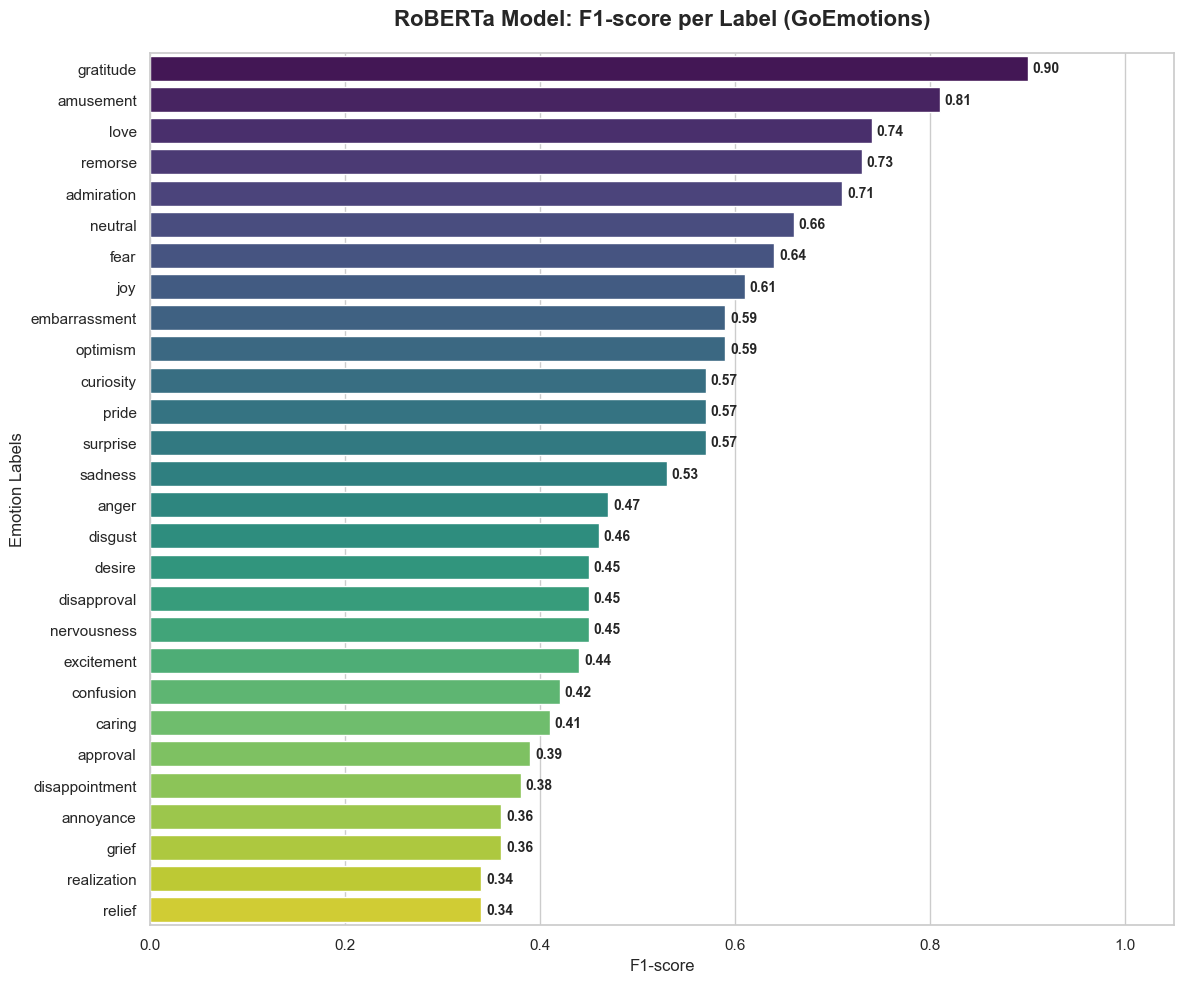

In [2]:
roberta_data = {
    'Label': [
        'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring',
        'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval',
        'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief',
        'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization',
        'relief', 'remorse', 'sadness', 'surprise', 'neutral'
    ],
    'F1-score': [
        0.71, 0.81, 0.47, 0.36, 0.39, 0.41, 0.42, 0.57, 0.45, 0.38, 0.45,
        0.46, 0.59, 0.44, 0.64, 0.90, 0.36, 0.61, 0.74, 0.45, 0.59, 0.57,
        0.34, 0.34, 0.73, 0.53, 0.57, 0.66
    ]
}

f1_scores_roberta = dict(zip(roberta_data['Label'], roberta_data['F1-score']))
sorted_f1_roberta = dict(sorted(f1_scores_roberta.items(), key=lambda item: item[1], reverse=True))

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 10))

# Vẽ biểu đồ cột ngang
ax = sns.barplot(
    x=list(sorted_f1_roberta.values()),
    y=list(sorted_f1_roberta.keys()),
    hue=list(sorted_f1_roberta.keys()),
    palette='viridis'
)

if ax.get_legend():
    ax.get_legend().remove()

for i, (label, v) in enumerate(sorted_f1_roberta.items()):
    ax.text(v + 0.005, i, f'{v:.2f}', va='center', fontsize=10, fontweight='bold')

plt.title('RoBERTa Model: F1-score per Label (GoEmotions)', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('F1-score', fontsize=12)
plt.ylabel('Emotion Labels', fontsize=12)
plt.xlim(0, 1.05)

plt.tight_layout()
plt.savefig('roberta_f1_chart.png', dpi=300)
plt.show()